# Cervical Cancer Risk Prediction — Colab Notebook

## Project objective
This notebook builds a **professional, presentation-ready machine learning project** to predict **`Biopsy`** outcomes from cervical cancer risk factors.

## Why this notebook is designed this way
We follow an end-to-end workflow inspired by the first seven chapters of *Hands-On Machine Learning*:
- data preparation
- exploratory data analysis
- preprocessing pipelines
- regularization
- model comparison
- cross-validation
- hyperparameter tuning
- feature interpretation

## Important note
We use **`Biopsy`** as the main target because it is the clearest final diagnostic outcome for a binary classification problem.

We **remove `Hinselmann`, `Schiller`, and `Citology` from the input features** because they are other diagnosis-related outputs. Keeping them would create **data leakage** and make the model look unrealistically strong.

## What this notebook includes
This notebook includes:
- missing-value analysis
- histograms
- bar charts
- boxplots
- heatmaps
- scatter plots
- ROC and Precision-Recall curves
- feature importance plots
- an optional 2D decision-boundary visualization
- an optional decision-tree plot

This makes the project look both **analytical** and **presentation-ready**.

## Step 1 — Import the libraries

### What we do
We import the libraries for data analysis, visualization, preprocessing, modeling, tuning, and evaluation.

### Why we do it
A clean import section makes the notebook easier to understand and reuse.

### What we use and why
- **Pandas / NumPy** for data work
- **Matplotlib / Seaborn / Plotly** for strong visuals
- **Scikit-Learn** for pipelines, models, validation, and tuning

### Why this matters
This creates a complete working environment for the whole project.

In [35]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    make_scorer
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pio.renderers.default = "colab"

## Step 2 — Upload and load the dataset

### What we do
We upload the CSV file into Google Colab and load it into a DataFrame.

### Why we do it
The notebook should be easy to run in Colab without hard-coded local file paths.

### What we use and why
We use `google.colab.files.upload()` because it is the simplest way to load a CSV into Colab.

### Why this matters
This makes the notebook portable and easy for your instructor to run.

In [36]:
from google.colab import files

uploaded = files.upload()
file_name = next(iter(uploaded))

df = pd.read_csv(file_name, na_values="?")
df.head()

Saving risk_factors_cervical_cancer.csv to risk_factors_cervical_cancer (2).csv


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,NaN,NaN,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0


## Step 3 — Basic dataset audit

### What we do
We inspect the shape, data types, missing values, and duplicated rows.

### Why we do it
A professional ML project always starts with a data audit before cleaning or modeling.

### What we use and why
We use fast Pandas inspection commands because they clearly show the quality of the raw data.

### Why this matters
It helps us detect missing values, wrong data types, and duplicated records early.

In [37]:
print("Dataset shape:", df.shape)
print("\nData types:\n")
print(df.dtypes)

print("\nMissing values per column:\n")
print(df.isna().sum().sort_values(ascending=False))

print("\nDuplicated rows:", df.duplicated().sum())

Dataset shape: (858, 36)

Data types:

Age                                     int64
Number of sexual partners             float64
First sexual intercourse              float64
Num of pregnancies                    float64
Smokes                                float64
Smokes (years)                        float64
Smokes (packs/year)                   float64
Hormonal Contraceptives               float64
Hormonal Contraceptives (years)       float64
IUD                                   float64
IUD (years)                           float64
STDs                                  float64
STDs (number)                         float64
STDs:condylomatosis                   float64
STDs:cervical condylomatosis          float64
STDs:vaginal condylomatosis           float64
STDs:vulvo-perineal condylomatosis    float64
STDs:syphilis                         float64
STDs:pelvic inflammatory disease      float64
STDs:genital herpes                   float64
STDs:molluscum contagiosum            flo

## Step 4 — Convert columns to numeric

### What we do
We convert all columns to numeric format when possible.

### Why we do it
Machine learning models in Scikit-Learn need numeric inputs.

### What we use and why
We use `pd.to_numeric(..., errors="coerce")` so non-numeric values become `NaN`, which we can handle later.

### Why this matters
This is an important cleaning step before preprocessing and model training.

In [38]:
df = df.apply(pd.to_numeric, errors="coerce")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 858 non-null    int64  
 1   Number of sexual partners           832 non-null    float64
 2   First sexual intercourse            851 non-null    float64
 3   Num of pregnancies                  802 non-null    float64
 4   Smokes                              845 non-null    float64
 5   Smokes (years)                      845 non-null    float64
 6   Smokes (packs/year)                 845 non-null    float64
 7   Hormonal Contraceptives             750 non-null    float64
 8   Hormonal Contraceptives (years)     750 non-null    float64
 9   IUD                                 741 non-null    float64
 10  IUD (years)                         741 non-null    float64
 11  STDs                                753 non-n

## Step 5 — Quick summary statistics

### What we do
We generate descriptive statistics for the dataset.

### Why we do it
This gives us a fast overview of feature scale, spread, and possible outliers.

### What we use and why
We use `describe()` because it is the standard first statistical summary for tabular data.

### Why this matters
This helps us understand the data before visualization and preprocessing.

In [39]:
summary_stats = df.describe().T
summary_stats

,count,mean,std,min,25%,50%,75%,max
Age,858.0,26.820513,8.497948,13.0,20.0,25.0,32.0,84.0
Number of sexual partners,832.0,2.527644,1.667760,1.0,2.0,2.0,3.0,28.0
First sexual intercourse,851.0,16.995300,2.803355,10.0,15.0,17.0,18.0,32.0
Num of pregnancies,802.0,2.275561,1.447414,0.0,1.0,2.0,3.0,11.0
Smokes,845.0,0.145562,0.352876,0.0,0.0,0.0,0.0,1.0
Smokes (years),845.0,1.219721,4.089017,0.0,0.0,0.0,0.0,37.0
Smokes (packs/year),845.0,0.453144,2.226610,0.0,0.0,0.0,0.0,37.0
Hormonal Contraceptives,750.0,0.641333,0.479929,0.0,0.0,1.0,1.0,1.0
Hormonal Contraceptives (years),750.0,2.256419,3.764254,0.0,0.0,0.5,3.0,30.0
IUD,741.0,0.112011,0.315593,0.0,0.0,0.0,0.0,1.0


# Requirement 1 — Data Preparation

## Small documentation
### What we did
We checked the dataset, converted it to numeric form, and inspected missing values and duplicates.

### Why we did this
Raw data usually contains quality problems. If we ignore them, our model becomes unreliable.

### What we used and why
We used Pandas because it is the standard tool for loading and cleaning tabular data.

### Why this step is important
Good modeling starts with good data.

### Why we did this instead of jumping directly to models
If we train first and clean later, we risk learning from broken or misleading data.

## Step 6 — Check the target variable

### What we do
We inspect the class distribution for `Biopsy`.

### Why we do it
This is a classification problem, and class imbalance affects how we should evaluate the models.

### What we use and why
We use value counts because it is the fastest way to understand the target balance.

### Why this matters
If the positive class is rare, accuracy alone is not enough.

In [40]:
target = "Biopsy"

print(df[target].value_counts())
print("\nClass percentages:\n")
print((df[target].value_counts(normalize=True) * 100).round(2))

Biopsy
0    803
1     55
Name: count, dtype: int64

Class percentages:

Biopsy
0    93.59
1     6.41
Name: proportion, dtype: float64


## Step 7 — Plot the target distribution

### What we do
We visualize how many negative and positive biopsy cases exist.

### Why we do it
A chart is easier to explain in a presentation than a plain table.

### What we use and why
We use Plotly for an interactive and polished presentation-style chart.

### Why this matters
It quickly shows whether the dataset is balanced or not.

In [41]:
fig = px.histogram(
    df,
    x=target,
    color=df[target].astype(str),
    text_auto=True,
    title="Biopsy Class Distribution"
)
fig.update_layout(xaxis_title="Biopsy", yaxis_title="Count", showlegend=False)
fig.show()

## Step 8 — Visualize missing values

### What we do
We calculate the percentage of missing values in each column and plot them.

### Why we do it
Missing-value analysis helps us decide which columns to impute and which columns to drop.

### What we use and why
We use Plotly so the result looks clean and easy to discuss in the presentation.

### Why this matters
This directly supports the data preparation requirement.

In [42]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_df = missing_pct.reset_index()
missing_df.columns = ["Feature", "MissingPercent"]

fig = px.bar(
    missing_df,
    x="MissingPercent",
    y="Feature",
    orientation="h",
    title="Missing Value Percentage by Feature"
)
fig.update_layout(yaxis={"categoryorder": "total ascending"})
fig.show()

# Requirement 2 — Exploratory Data Analysis (EDA)

## Small documentation
### What we did
We explored distributions, outliers, missing values, class balance, and feature relationships.

### Why we did this
EDA helps us understand the structure of the dataset and identify meaningful patterns before modeling.

### What we used and why
We used Matplotlib, Seaborn, and Plotly because together they provide both strong statistical visuals and presentation-friendly charts.

### Why this step is important
EDA helps us find class imbalance, suspicious variables, and useful features.

### Why we did this instead of only using summary tables
Visuals reveal patterns much faster and make the notebook more professional.

## Step 9 — Histograms for key numerical features

### What we do
We plot histograms for important numerical features.

### Why we do it
Histograms help us understand skewness, spread, and concentration of values.

### What we use and why
We use Plotly histograms because they are interactive and visually strong.

### Why this matters
This helps us understand the patient population and supports feature discussion.

In [43]:
selected_cols = [
    "Age",
    "Number of sexual partners",
    "First sexual intercourse",
    "Num of pregnancies",
    "Smokes (years)",
    "Hormonal Contraceptives (years)",
    "IUD (years)"
]

for col in selected_cols:
    if col in df.columns:
        fig = px.histogram(df, x=col, nbins=30, title=f"Distribution of {col}")
        fig.show()

## Step 10 — Boxplots for outlier inspection

### What we do
We plot boxplots for selected numerical features.

### Why we do it
Boxplots help us identify extreme values and possible outliers.

### What we use and why
We use Seaborn/Matplotlib because boxplots are simple and clear in static form.

### Why this matters
This is useful because outliers can affect scaling and some model families.

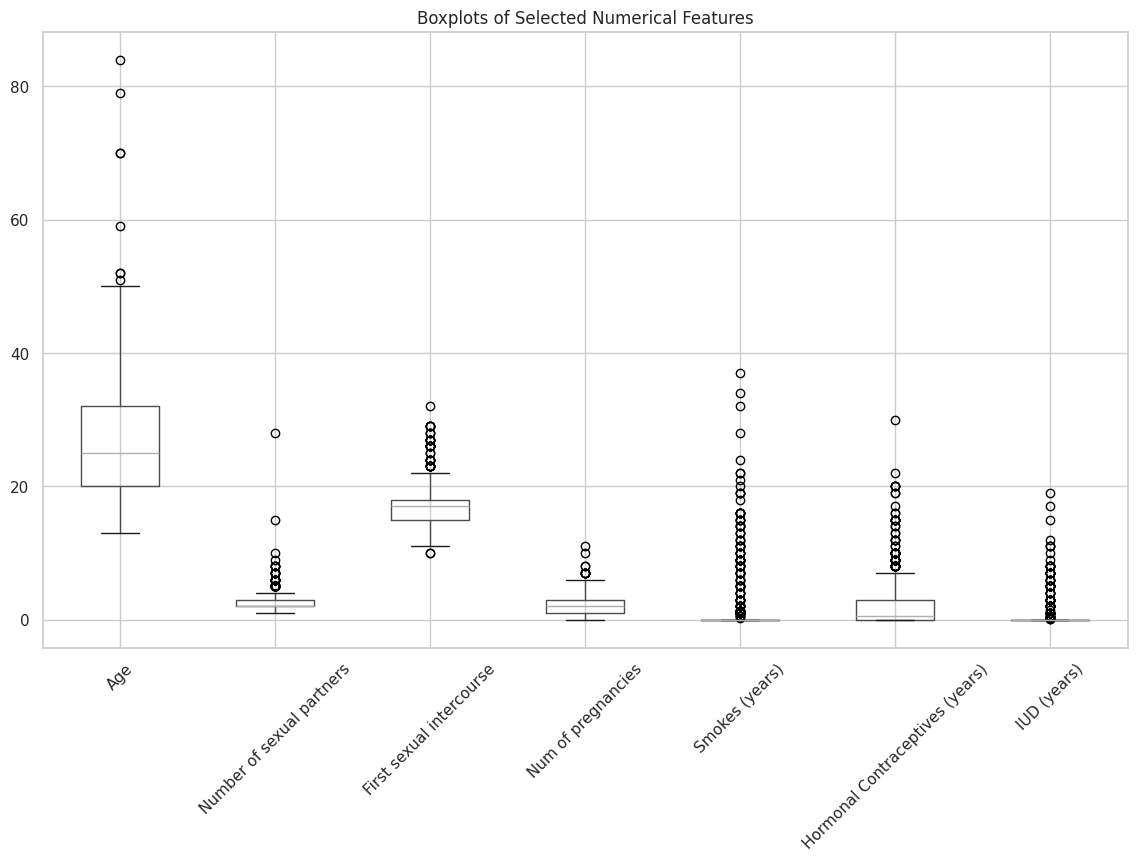

In [44]:
boxplot_cols = [col for col in selected_cols if col in df.columns]

plt.figure(figsize=(14, 8))
df[boxplot_cols].boxplot(rot=45)
plt.title("Boxplots of Selected Numerical Features")
plt.show()

## Step 11 — Correlation heatmap

### What we do
We compute a correlation matrix and visualize it as a heatmap.

### Why we do it
This helps us see which features move together and which features may be more related to the target.

### What we use and why
We use Seaborn because it gives a clear high-density heatmap for many variables.

### Why this matters
A correlation heatmap is one of the strongest EDA visuals in a presentation.

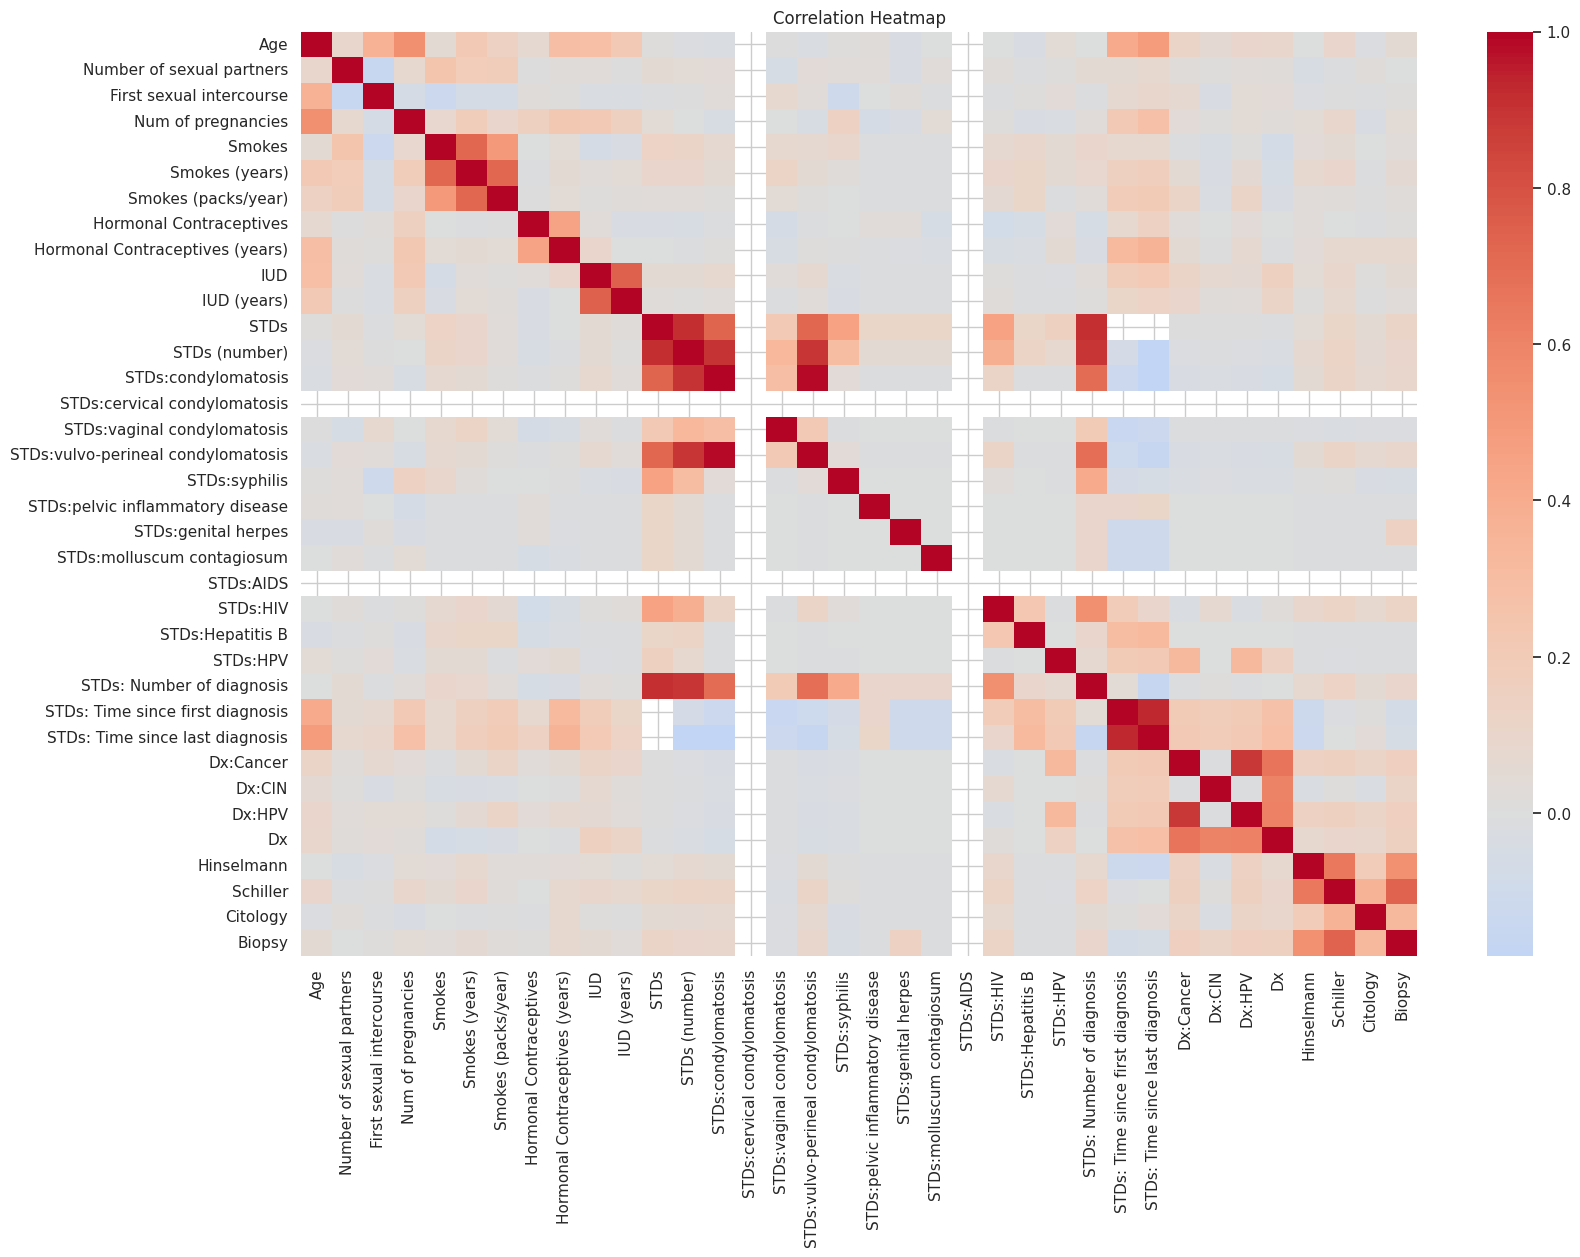

In [45]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(18, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

## Step 12 — Features most correlated with the target

### What we do
We sort all feature correlations with `Biopsy`.

### Why we do it
This helps us discuss which variables may be most useful for prediction.

### What we use and why
We use the correlation matrix because it gives a quick ranking of feature-target relationships.

### Why this matters
This supports the midterm presentation requirement about best features and correlations.

In [46]:
target_corr = corr_matrix[target].sort_values(key=lambda x: x.abs(), ascending=False)
target_corr.to_frame(name="Correlation_with_Biopsy").head(15)

,Correlation_with_Biopsy
Biopsy,1.000000
Schiller,0.733204
Hinselmann,0.547417
Citology,0.327466
Dx:Cancer,0.160905
Dx:HPV,0.160905
Dx,0.157607
STDs:genital herpes,0.132526
STDs:HIV,0.126880
Dx:CIN,0.113172


## Step 13 — Visualize the strongest target correlations

### What we do
We plot the strongest feature correlations with `Biopsy`.

### Why we do it
A chart is easier to present than a long numeric table.

### What we use and why
We use Plotly for a clean and presentation-ready horizontal bar chart.

### Why this matters
This helps explain which factors seem most relevant before modeling.

In [47]:
top_corr = target_corr.drop(target).head(12).sort_values()

fig = px.bar(
    x=top_corr.values,
    y=top_corr.index,
    orientation="h",
    title="Top Feature Correlations with Biopsy"
)
fig.update_layout(xaxis_title="Correlation", yaxis_title="Feature")
fig.show()

## Step 14 — Compare feature distributions by target

### What we do
We compare important numerical features across biopsy classes.

### Why we do it
This helps us see whether positive and negative cases behave differently.

### What we use and why
We use boxplots grouped by the target because they show differences between classes clearly.

### Why this matters
This is useful when explaining why some features may help classification.

In [48]:
compare_cols = ["Age", "Number of sexual partners", "Num of pregnancies", "Smokes (years)"]

for col in compare_cols:
    if col in df.columns:
        fig = px.box(
            df,
            x=target,
            y=col,
            color=df[target].astype(str),
            title=f"{col} by Biopsy Result"
        )
        fig.update_layout(showlegend=False)
        fig.show()

## Step 15 — Interactive scatter plot

### What we do
We create an interactive scatter plot using two intuitive variables.

### Why we do it
Scatter plots are useful for visually exploring class overlap and cluster patterns.

### What we use and why
We use Plotly because zooming and hovering are useful in a presentation.

### Why this matters
It gives the notebook a more polished and interactive feel.

In [49]:
if "Age" in df.columns and "Number of sexual partners" in df.columns:
    fig = px.scatter(
        df,
        x="Age",
        y="Number of sexual partners",
        color=df[target].astype(str),
        title="Age vs Number of Sexual Partners",
        opacity=0.7
    )
    fig.show()

# Requirement 3 — Data Preprocessing and Data Regularization

## Small documentation
### What we did
We selected the target, removed leakage columns, dropped columns with extremely high missingness, split the data, and created preprocessing pipelines.

### Why we did this
A strong ML system needs a clean and repeatable preprocessing workflow.

### What we used and why
We used `Pipeline` and `ColumnTransformer` because they keep preprocessing modular, safe, and reusable.

### Why this step is important
This avoids leakage and ensures the same transformations are used for train and test data.

### Why we did this instead of manual preprocessing in many separate cells
Manual preprocessing is harder to maintain and easier to get wrong.

## Step 16 — Define the target and remove leakage columns

### What we do
We keep `Biopsy` as the target and remove diagnosis-output columns from the feature set.

### Why we do it
Those diagnosis outputs would leak future information into the model.

### What we use and why
We use simple column dropping because the leakage columns are known in advance.

### Why this matters
Leakage can produce unrealistic results and hurt the credibility of the project.

In [50]:
target = "Biopsy"
leakage_cols = ["Hinselmann", "Schiller", "Citology", "Biopsy"]

X = df.drop(columns=leakage_cols)
y = df[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (858, 32)
Target shape: (858,)


## Step 17 — Drop columns with extremely high missing values

### What we do
We remove columns with more than 70% missing values.

### Why we do it
When a feature is missing in most rows, it often adds noise rather than value.

### What we use and why
We use a simple missingness threshold because it is easy to justify in a report.

### Why this matters
This improves data quality and keeps the model cleaner.

In [51]:
high_missing_cols = X.columns[X.isna().mean() > 0.70].tolist()
print("Columns dropped for very high missingness:", high_missing_cols)

X = X.drop(columns=high_missing_cols)
print("New feature shape:", X.shape)

Columns dropped for very high missingness: ['STDs: Time since first diagnosis', 'STDs: Time since last diagnosis']
New feature shape: (858, 30)


## Step 18 — Train-test split with stratification

### What we do
We split the data into training and test sets using stratification.

### Why we do it
The target is imbalanced, so we want both sets to keep a similar class ratio.

### What we use and why
We use `train_test_split(..., stratify=y)` because it is the standard way to create a fair holdout set.

### Why this matters
This makes the final test evaluation more reliable.

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("\nTrain class ratio:\n", y_train.value_counts(normalize=True).round(3))
print("\nTest class ratio:\n", y_test.value_counts(normalize=True).round(3))

X_train: (686, 30)
X_test : (172, 30)

Train class ratio:
 Biopsy
0    0.936
1    0.064
Name: proportion, dtype: float64

Test class ratio:
 Biopsy
0    0.936
1    0.064
Name: proportion, dtype: float64


## Step 19 — Build preprocessing pipelines

### What we do
We create:
1. a scaled pipeline for Logistic Regression and SVM
2. a non-scaled pipeline for tree-based models

### Why we do it
Some models depend on feature scale, while tree models usually do not.

### What we use and why
We use:
- `SimpleImputer(strategy="median")` for missing values
- `StandardScaler()` for scale-sensitive models
- `Pipeline` and `ColumnTransformer` for modular design

### Why this matters
This is a key professional design choice in a production-style notebook.

In [53]:
numeric_features = X_train.columns.tolist()

scaled_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features)
    ]
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), numeric_features)
    ]
)

## Step 20 — Regularization setup

### What we do
We prepare regularized Logistic Regression models with **L1** and **L2** penalties.

### Why we do it
Regularization helps control overfitting.

### What we use and why
- **L1** can shrink some coefficients toward zero
- **L2** keeps all features but reduces coefficient size

### Why this matters
Regularization is one of the required project elements and is directly aligned with classical ML methods.

In [54]:
log_reg_l1 = Pipeline([
    ("prep", scaled_preprocessor),
    ("model", LogisticRegression(
        max_iter=3000,
        solver="liblinear",
        penalty="l1",
        class_weight="balanced",
        random_state=42
    ))
])

log_reg_l2 = Pipeline([
    ("prep", scaled_preprocessor),
    ("model", LogisticRegression(
        max_iter=3000,
        solver="liblinear",
        penalty="l2",
        class_weight="balanced",
        random_state=42
    ))
])

# Requirement 4 — Model Selection and Training

## Small documentation
### What we did
We trained several classical machine learning models and compared them fairly.

### Why we did this
A professional ML project should not assume one algorithm is best before testing.

### What we used and why
We selected models that fit the project scope and the book scope:
- Logistic Regression
- SVM
- Decision Tree
- Random Forest

### Why this step is important
Different models behave differently on noisy, imbalanced, and incomplete data.

### Why we did this instead of picking one model immediately
Model comparison is more scientific and gives stronger justification for the final choice.

## Step 21 — Define the candidate models

### What we do
We define at least three candidate models, including a regularized baseline and tree-based ensembles.

### Why we do it
This creates a fair comparison across different model families.

### What we use and why
- **Logistic Regression** for a regularized linear baseline
- **SVM** for margin-based classification
- **Decision Tree** for interpretability
- **Random Forest** for ensemble strength

### Why this matters
This directly satisfies the model selection requirement.

In [55]:
svm_model = Pipeline([
    ("prep", scaled_preprocessor),
    ("model", SVC(
        kernel="rbf",
        class_weight="balanced",
        random_state=42
    ))
])

decision_tree_model = Pipeline([
    ("prep", tree_preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=5,
        class_weight="balanced",
        random_state=42
    ))
])

random_forest_model = Pipeline([
    ("prep", tree_preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42
    ))
])

models = {
    "Logistic Regression (L1)": log_reg_l1,
    "Logistic Regression (L2)": log_reg_l2,
    "SVM (RBF)": svm_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
}

## Step 22 — Cross-validation setup

### What we do
We create a stratified cross-validation strategy and define multiple evaluation metrics.

### Why we do it
A single split can be unstable. Cross-validation gives a more reliable comparison.

### What we use and why
We use:
- **StratifiedKFold** to preserve class balance in each fold
- **Accuracy, Precision, Recall, F1, ROC-AUC** for a fuller view of model quality

### Why this matters
This adds rigor to the project and matches the evaluation standards expected in a senior-level workflow.

In [56]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": make_scorer(accuracy_score),
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc"
}

## Step 23 — Compare all models with cross-validation

### What we do
We evaluate all candidate models on the training data using the same cross-validation process.

### Why we do it
This creates a fair comparison and helps us select the strongest candidates for tuning.

### What we use and why
We use `cross_validate` so we can compute multiple metrics at the same time.

### Why this matters
This is the core comparison step of the modeling phase.

In [57]:
results = []

for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

    results.append({
        "Model": name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "CV ROC-AUC": scores["test_roc_auc"].mean()
    })

cv_results = pd.DataFrame(results).sort_values(by="CV ROC-AUC", ascending=False)
cv_results

,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC
2,SVM (RBF),0.902296,0.295201,0.297222,0.284524,0.694870
0,Logistic Regression (L1),0.794478,0.151925,0.472222,0.227402,0.654199
4,Random Forest,0.932931,0.200000,0.022222,0.040000,0.647096
1,Logistic Regression (L2),0.795927,0.147932,0.450000,0.219777,0.617091
3,Decision Tree,0.743700,0.072647,0.266667,0.110773,0.443045


## Step 24 — Visual comparison of model performance

### What we do
We turn the cross-validation results into a comparison chart.

### Why we do it
Charts are easier to explain in a presentation than raw tables.

### What we use and why
We use Plotly grouped bars for a clean comparison across several metrics.

### Why this matters
This makes the model-selection section look strong and polished.

In [58]:
melted = cv_results.melt(id_vars="Model", var_name="Metric", value_name="Score")

fig = px.bar(
    melted,
    x="Model",
    y="Score",
    color="Metric",
    barmode="group",
    title="Cross-Validation Performance Comparison"
)
fig.update_layout(xaxis_tickangle=-20)
fig.show()

# Requirement 5 — Model Evaluation

## Small documentation
### What we did
We selected the strongest models, tuned them, and evaluated the final choice on the unseen test set.

### Why we did this
Cross-validation is used during development, but the final quality must be checked on unseen data.

### What we used and why
We used:
- GridSearchCV
- RandomizedSearchCV
- confusion matrix
- classification report
- ROC curve
- Precision-Recall curve

### Why this step is important
It tells us whether the model really generalizes well.

### Why we did this instead of reporting only accuracy
The target is imbalanced, so accuracy alone can hide weak performance on the positive class.

## Step 25 — Tune a regularized Logistic Regression model

### What we do
We tune the penalty strength of Logistic Regression.

### Why we do it
Default values are not always the best.

### What we use and why
We use `GridSearchCV` because the hyperparameter space is small and structured.

### Why this matters
This improves the baseline in a systematic and reproducible way.

In [59]:
log_reg_grid = Pipeline([
    ("prep", scaled_preprocessor),
    ("model", LogisticRegression(
        max_iter=3000,
        solver="liblinear",
        class_weight="balanced",
        random_state=42
    ))
])

log_param_grid = {
    "model__penalty": ["l1", "l2"],
    "model__C": [0.01, 0.1, 1, 10, 50]
}

log_grid_search = GridSearchCV(
    estimator=log_reg_grid,
    param_grid=log_param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1
)

log_grid_search.fit(X_train, y_train)

print("Best Logistic Regression Params:", log_grid_search.best_params_)
print("Best Logistic Regression ROC-AUC:", round(log_grid_search.best_score_, 4))

Best Logistic Regression Params: {'model__C': 0.01, 'model__penalty': 'l2'}
Best Logistic Regression ROC-AUC: 0.6718


## Step 26 — Tune a Random Forest model

### What we do
We tune important Random Forest hyperparameters.

### Why we do it
Ensemble models can improve a lot when their depth and splitting rules are adjusted.

### What we use and why
We use `RandomizedSearchCV` because it explores a wider space with less computation than a full grid.

### Why this matters
This gives us a stronger tuned ensemble candidate.

In [60]:
rf_random = Pipeline([
    ("prep", tree_preprocessor),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ))
])

rf_param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 3, 5, 7, 10],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

rf_random_search = RandomizedSearchCV(
    estimator=rf_random,
    param_distributions=rf_param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1
)

rf_random_search.fit(X_train, y_train)

print("Best Random Forest Params:", rf_random_search.best_params_)
print("Best Random Forest ROC-AUC:", round(rf_random_search.best_score_, 4))

Best Random Forest Params: {'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_depth': None}
Best Random Forest ROC-AUC: 0.6598


## Step 27 — Tune an SVM model

### What we do
We tune the SVM margin strength and kernel settings.

### Why we do it
SVM performance can change a lot with the right `C` and `gamma`.

### What we use and why
We use a small `GridSearchCV` to keep the search strong but still practical in Colab.

### Why this matters
This gives us a tuned candidate from the SVM family, which is one of the required model families.

In [61]:
svm_grid = Pipeline([
    ("prep", scaled_preprocessor),
    ("model", SVC(
        class_weight="balanced",
        random_state=42
    ))
])

svm_param_grid = {
    "model__kernel": ["rbf"],
    "model__C": [0.1, 1, 5, 10],
    "model__gamma": ["scale", 0.1, 0.01]
}

svm_grid_search = GridSearchCV(
    estimator=svm_grid,
    param_grid=svm_param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1
)

svm_grid_search.fit(X_train, y_train)

print("Best SVM Params:", svm_grid_search.best_params_)
print("Best SVM ROC-AUC:", round(svm_grid_search.best_score_, 4))

Best SVM Params: {'model__C': 0.1, 'model__gamma': 0.1, 'model__kernel': 'rbf'}
Best SVM ROC-AUC: 0.6958


## Step 28 — Select the best tuned model

### What we do
We compare the best tuned Logistic Regression, Random Forest, and SVM models.

### Why we do it
We want a fair final choice based on the same validation metric.

### What we use and why
We use ROC-AUC because the target is imbalanced and ranking quality matters.

### Why this matters
This finalizes the strongest model for test evaluation.

In [62]:
tuned_models = {
    "Best Tuned Logistic Regression": log_grid_search.best_estimator_,
    "Best Tuned Random Forest": rf_random_search.best_estimator_,
    "Best Tuned SVM": svm_grid_search.best_estimator_
}

tuned_scores = {
    "Best Tuned Logistic Regression": log_grid_search.best_score_,
    "Best Tuned Random Forest": rf_random_search.best_score_,
    "Best Tuned SVM": svm_grid_search.best_score_
}

best_model_name = max(tuned_scores, key=tuned_scores.get)
best_model = tuned_models[best_model_name]

print("Selected Final Model:", best_model_name)
print("Validation ROC-AUC:", round(tuned_scores[best_model_name], 4))

Selected Final Model: Best Tuned SVM
Validation ROC-AUC: 0.6958


## Step 29 — Fit the final model and generate predictions

### What we do
We train the selected model on the training data and evaluate it on the test set.

### Why we do it
The test set gives us the final estimate of generalization performance.

### What we use and why
We use the same train/test split created earlier so that the evaluation remains honest.

### Why this matters
This is the most important performance check in the notebook.

In [63]:
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

if hasattr(best_model, "predict_proba"):
    y_score = best_model.predict_proba(X_test)[:, 1]
else:
    y_score = best_model.decision_function(X_test)

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, y_pred, zero_division=0), 4))
print("F1-score :", round(f1_score(y_test, y_pred, zero_division=0), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_score), 4))

Accuracy : 0.7674
Precision: 0.1081
Recall   : 0.3636
F1-score : 0.1667
ROC-AUC  : 0.6138


## Step 30 — Full classification report

### What we do
We print precision, recall, and F1-score for each class.

### Why we do it
This is more informative than overall accuracy, especially in medical classification.

### What we use and why
We use `classification_report` because it is a standard summary of class-level performance.

### Why this matters
This helps us explain strengths and weaknesses clearly.

In [64]:
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.95      0.80      0.86       161
           1       0.11      0.36      0.17        11

    accuracy                           0.77       172
   macro avg       0.53      0.58      0.52       172
weighted avg       0.89      0.77      0.82       172



## Step 31 — Confusion matrix

### What we do
We visualize the confusion matrix.

### Why we do it
It shows the exact number of true positives, false positives, true negatives, and false negatives.

### What we use and why
We use a heatmap because it is the clearest visual format for error analysis.

### Why this matters
In healthcare problems, understanding the type of errors is very important.

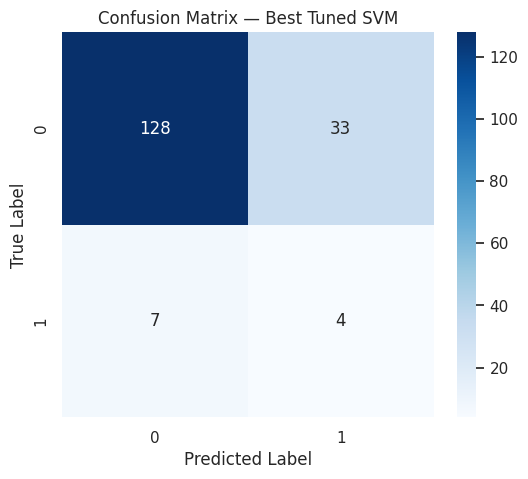

In [65]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Step 32 — ROC curve

### What we do
We plot the Receiver Operating Characteristic (ROC) curve.

### Why we do it
This shows how well the model separates the two classes across different thresholds.

### What we use and why
We use the model score values because ROC curves depend on ranking, not just hard labels.

### Why this matters
This is one of the most important visuals for binary classification.

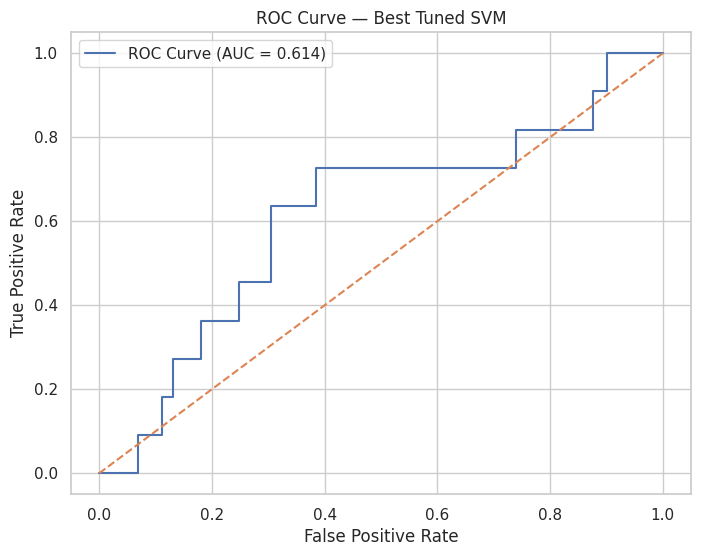

In [66]:
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = roc_auc_score(y_test, y_score)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve — {best_model_name}")
plt.legend()
plt.show()

## Step 33 — Precision-Recall curve

### What we do
We plot the Precision-Recall curve.

### Why we do it
This is especially useful when the positive class is much smaller than the negative class.

### What we use and why
We use continuous model scores to trace the precision-recall tradeoff.

### Why this matters
It gives a better view of minority-class performance.

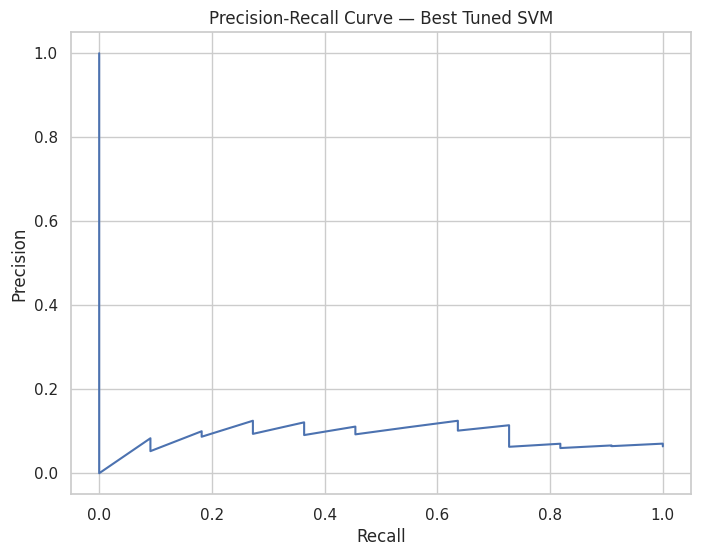

In [67]:
precision, recall, _ = precision_recall_curve(y_test, y_score)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve — {best_model_name}")
plt.show()

# Requirement 6 — Presentation of Correlations and Best Features

## Small documentation
### What we did
We identified and visualized the most important features in the final model.

### Why we did this
A good project should not only predict well but also explain what drives the predictions.

### What we used and why
- `feature_importances_` for Random Forest
- coefficient magnitudes for Logistic Regression
- absolute coefficient magnitudes for linear SVM

### Why this step is important
Stakeholders usually want both performance and interpretation.

### Why we did this instead of advanced explainability tools
Advanced explainability tools go beyond the requested scope. This notebook stays within the classical methods required for the project.

## Step 34 — Extract feature importance safely

### What we do
We extract feature importance from the final model if it supports it.

### Why we do it
Some models, like Random Forest and Logistic Regression, give direct importance values.
But some models, like **SVM with RBF kernel**, do not provide simple feature importance.

### What we use and why
- `feature_importances_` for Random Forest
- `coef_` for Logistic Regression or linear-margin models
- a fallback **Random Forest interpretation model** if the final model is nonlinear SVM

### Why this matters
This makes the notebook work no matter which model wins, and it still gives you a strong feature-importance graph for presentation.

In [68]:
feature_names = X_train.columns.tolist()
final_estimator = best_model.named_steps["model"]

# Case 1: Tree-based models
if hasattr(final_estimator, "feature_importances_"):
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": final_estimator.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    print(f"Using direct feature importances from: {best_model_name}")

# Case 2: Linear models
elif hasattr(final_estimator, "coef_"):
    coef_values = final_estimator.coef_[0]
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": np.abs(coef_values),
        "Signed_Value": coef_values
    }).sort_values(by="Importance", ascending=False)

    print(f"Using absolute coefficient values from: {best_model_name}")

# Case 3: Nonlinear SVM or another model without direct feature importance
else:
    print(f"{best_model_name} does not provide direct feature importance.")
    print("Training a Random Forest only for interpretation...")

    # prepare data the simple way for interpretation
    interpret_imputer = SimpleImputer(strategy="median")
    X_train_interp = interpret_imputer.fit_transform(X_train)

    interpret_model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    )
    interpret_model.fit(X_train_interp, y_train)

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": interpret_model.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    print("Using Random Forest feature importance as an interpretation model.")

importance_df.head(15)

Best Tuned SVM does not provide direct feature importance.
Training a Random Forest only for interpretation...
Using Random Forest feature importance as an interpretation model.


,Feature,Importance
0,Age,0.183588
2,First sexual intercourse,0.147736
8,Hormonal Contraceptives (years),0.143115
3,Num of pregnancies,0.110926
1,Number of sexual partners,0.107448
6,Smokes (packs/year),0.032370
10,IUD (years),0.030331
5,Smokes (years),0.025764
29,Dx,0.025395
26,Dx:Cancer,0.023102


## Step 35 — Plot the most important features

### What we do
We visualize the top features from the final model.

### Why we do it
A ranked chart is much easier to discuss in a presentation than raw coefficients.

### What we use and why
We use a horizontal Plotly bar chart because it works well for feature names.

### Why this matters
This is one of the most useful interpretation visuals in the notebook.

In [69]:
top_features = importance_df.head(15).sort_values(by="Importance")

fig = px.bar(
    top_features,
    x="Importance",
    y="Feature",
    orientation="h",
    title=f"Top 15 Important Features — {best_model_name}"
)
fig.show()

# Extra Visual 1 — Optional 2D decision boundary

## Small documentation
### What we do
We build a simple **two-feature SVM** only for visualization and draw its decision boundary.

### Why we do this
Decision boundaries look great in presentations and help explain how classifiers separate classes.

### What we use and why
We use only two intuitive features so the boundary can be shown in 2D.

### Important note
This is **not** the final production model. It is a teaching and presentation visual.

## Step 36 — Train a 2D SVM for decision-boundary visualization

### What we do
We train an SVM on two features only: `Age` and `Number of sexual partners`.

### Why we do it
A real decision boundary can only be plotted directly in 2D.

### What we use and why
We use an SVM because margin-based classifiers produce nice and easy-to-see boundaries.

### Why this matters
This adds a high-quality visual element to the notebook.

In [70]:
viz_features = ["Age", "Number of sexual partners"]
viz_data = df[viz_features + [target]].dropna()

X_viz = viz_data[viz_features]
y_viz = viz_data[target]

X_viz_train, X_viz_test, y_viz_train, y_viz_test = train_test_split(
    X_viz, y_viz, test_size=0.2, stratify=y_viz, random_state=42
)

viz_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1, gamma="scale", class_weight="balanced", random_state=42))
])

viz_pipeline.fit(X_viz_train, y_viz_train)
print("2D SVM accuracy:", round(viz_pipeline.score(X_viz_test, y_viz_test), 4))

2D SVM accuracy: 0.521


## Step 37 — Plot the 2D decision boundary

### What we do
We create a mesh grid, predict the class on the grid, and visualize the decision regions.

### Why we do it
This lets us see how the classifier separates the space.

### What we use and why
We use Matplotlib contour plots because they are the standard choice for decision-boundary visuals.

### Why this matters
This gives the notebook an advanced but still chapter-aligned visual.

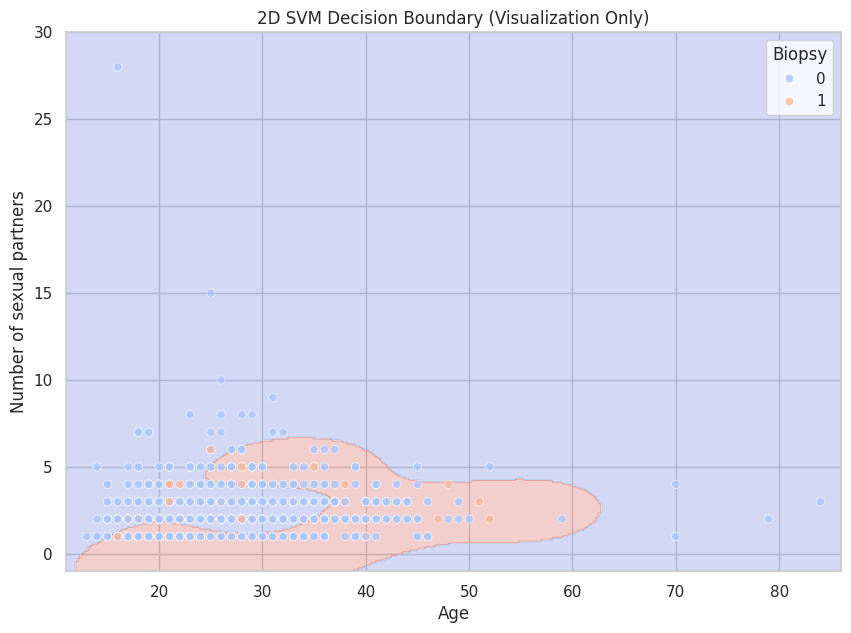

In [71]:
x_min, x_max = X_viz.iloc[:, 0].min() - 2, X_viz.iloc[:, 0].max() + 2
y_min, y_max = X_viz.iloc[:, 1].min() - 2, X_viz.iloc[:, 1].max() + 2

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = pd.DataFrame({
    viz_features[0]: xx.ravel(),
    viz_features[1]: yy.ravel()
})

Z = viz_pipeline.predict(grid).reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
sns.scatterplot(
    data=viz_data,
    x=viz_features[0],
    y=viz_features[1],
    hue=target,
    palette="coolwarm",
    alpha=0.8
)
plt.title("2D SVM Decision Boundary (Visualization Only)")
plt.show()

# Extra Visual 2 — Optional decision-tree plot

## Small documentation
### What we do
We train a shallow decision tree and visualize it.

### Why we do this
Decision trees are very interpretable and look good in a presentation.

### What we use and why
We keep the tree shallow so the plot stays readable.

### Important note
This tree is mainly for interpretation and presentation, not necessarily the final best model.

## Step 38 — Train and plot a shallow decision tree

### What we do
We impute missing values, fit a small decision tree, and plot it.

### Why we do it
A shallow tree gives an easy visual summary of how rule-based classification works.

### What we use and why
We use `plot_tree` because it is the standard built-in tree visualization in Scikit-Learn.

### Why this matters
This adds another strong model-interpretation visual to the notebook.

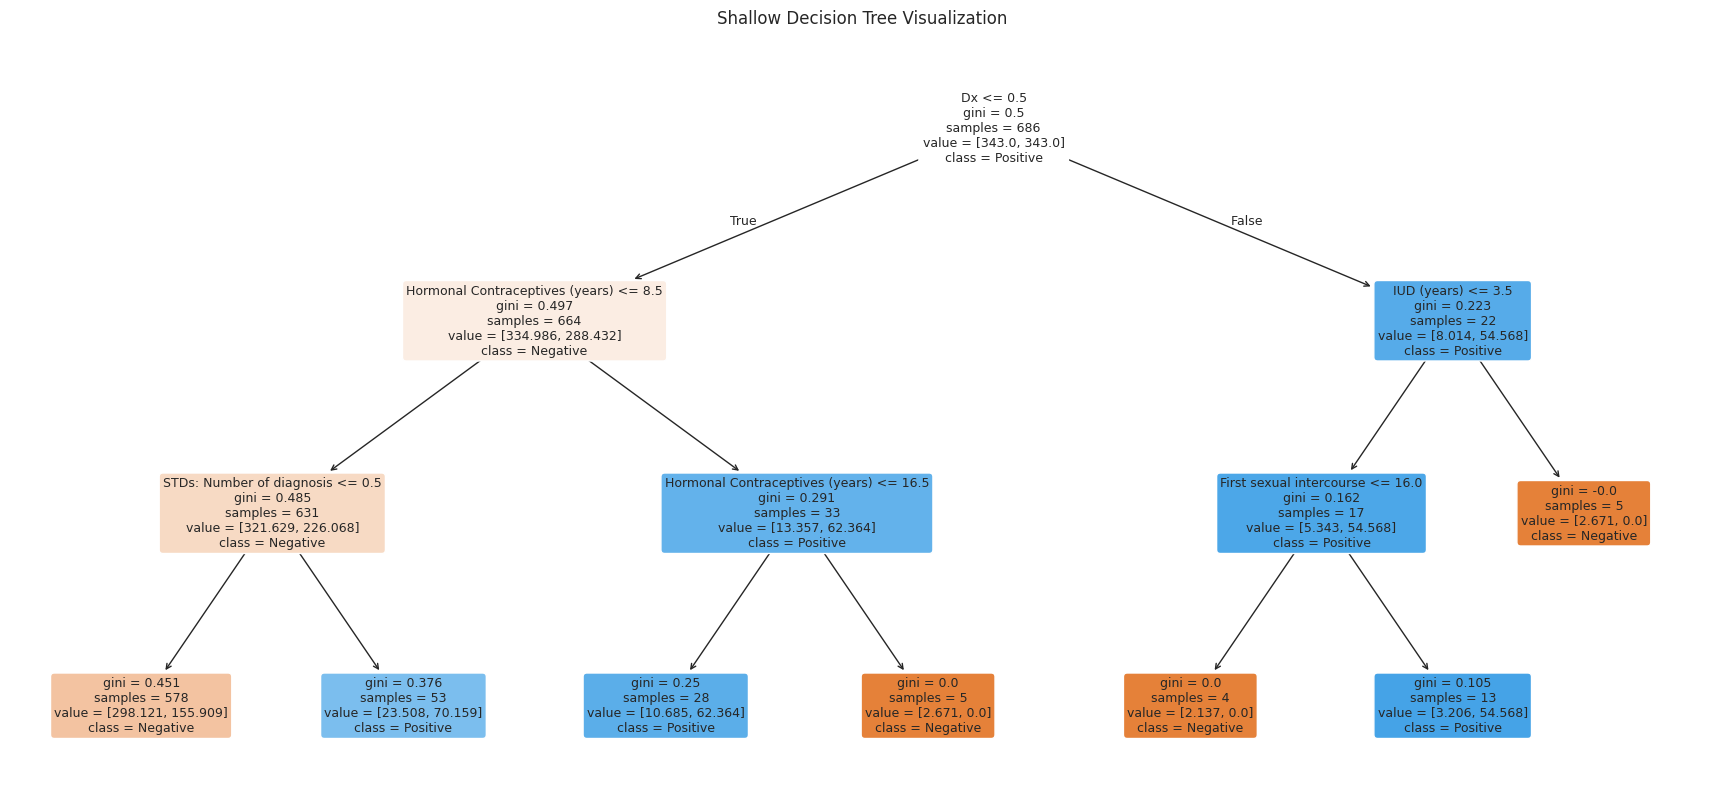

In [72]:
tree_imputer = SimpleImputer(strategy="median")
X_tree_ready = tree_imputer.fit_transform(X_train)

small_tree = DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=42)
small_tree.fit(X_tree_ready, y_train)

plt.figure(figsize=(22, 10))
plot_tree(
    small_tree,
    feature_names=X_train.columns,
    class_names=["Negative", "Positive"],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Shallow Decision Tree Visualization")
plt.show()

# Optional Ensemble Extension

## Small documentation
### What we did
We optionally combine strong models into one voting classifier.

### Why we did this
Ensemble methods are part of the required chapter range and can improve robustness.

### What we used and why
We use `VotingClassifier` because it is a clean and classical ensemble method.

### Why this step is useful
It adds extra depth to the project and shows stronger modeling maturity.

## Step 39 — Optional soft voting classifier

### What we do
We combine Logistic Regression, SVM, and Random Forest into one ensemble.

### Why we do it
Ensembles can reduce the weaknesses of any single model.

### What we use and why
We use soft voting because it combines probability-based confidence.

### Why this matters
This gives an extra chapter-7 ensemble result for the presentation.

In [73]:
voting_model = VotingClassifier(
    estimators=[
        ("lr", Pipeline([
            ("prep", scaled_preprocessor),
            ("model", LogisticRegression(
                max_iter=3000,
                solver="liblinear",
                penalty="l2",
                class_weight="balanced",
                random_state=42
            ))
        ])),
        ("svm", Pipeline([
            ("prep", scaled_preprocessor),
            ("model", SVC(
                kernel="rbf",
                probability=True,
                class_weight="balanced",
                random_state=42
            ))
        ])),
        ("rf", Pipeline([
            ("prep", tree_preprocessor),
            ("model", RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=42
            ))
        ]))
    ],
    voting="soft"
)

voting_model.fit(X_train, y_train)
voting_pred = voting_model.predict(X_test)
voting_proba = voting_model.predict_proba(X_test)[:, 1]

print("Voting Accuracy :", round(accuracy_score(y_test, voting_pred), 4))
print("Voting Precision:", round(precision_score(y_test, voting_pred, zero_division=0), 4))
print("Voting Recall   :", round(recall_score(y_test, voting_pred, zero_division=0), 4))
print("Voting F1-score :", round(f1_score(y_test, voting_pred, zero_division=0), 4))
print("Voting ROC-AUC  :", round(roc_auc_score(y_test, voting_proba), 4))

Voting Accuracy : 0.936
Voting Precision: 0.0
Voting Recall   : 0.0
Voting F1-score : 0.0
Voting ROC-AUC  : 0.6781


# Midterm Presentation Summary

## What we have done
- loaded and audited the cervical cancer dataset
- cleaned the data and converted it to numeric form
- analyzed missing values and removed high-missingness columns
- performed EDA using histograms, boxplots, heatmaps, and interactive charts
- removed leakage variables
- built preprocessing pipelines
- applied regularization with L1 and L2 Logistic Regression
- compared several classical ML models
- tuned strong candidates
- evaluated the final model on unseen data
- identified the most important features

## Main challenges
- missing values
- strong class imbalance
- possible leakage from diagnosis-output columns
- the need to compare several model families fairly

## Key findings
- the target is imbalanced, so accuracy alone is not enough
- some variables show stronger correlation with biopsy outcome than others
- regularized linear models, SVMs, and tree-based ensembles each offer different strengths
- the final selected model should be discussed using both performance metrics and feature interpretation

## Presentation tip
When you present this notebook, highlight:
1. why leakage removal was necessary
2. why stratified splitting and cross-validation were important
3. why regularization was included
4. why ROC-AUC, Precision, Recall, and F1 were all reported
5. which features appeared most important in the final model

# Final Conclusion

In this notebook, we built a complete machine learning workflow for predicting **Biopsy** outcomes from cervical cancer risk factors.

The project was designed to look:
- **professional**
- **well documented**
- **visual**
- **modular**
- **aligned with classical machine learning methods**

It includes strong visuals, preprocessing pipelines, regularization, model comparison, tuning, and interpretation.

This means the project is not just a model — it is a full, presentation-ready ML analysis notebook.